# 08 - Comparativo Final dos Modelos

## Objetivo

- Reunir os resultados salvos pelos notebooks 04 a 07.
- Comparar Regressão Logística, Random Forest, XGBoost e LightGBM.
- Avaliar Acurácia, Precision, Recall, AUC Score e tempo de treinamento.


## Visão geral

- Este notebook reúne os resultados dos modelos treinados e monta o comparativo final.
- Os comentários explicam a leitura dos arquivos `.json`, a geração de tabelas e gráficos, a comparação por AUC/Precision/Recall, as curvas ROC e a criação de um ensemble por soft voting.


## 1. Importações e Carregamento dos Resultados

- Esta célula carrega as métricas salvas pelos notebooks de modelagem e monta uma tabela comparativa.
- A exclusão do ensemble evita duplicidade quando o notebook é executado mais de uma vez.


In [1]:
import sys
sys.path.append('../src')

import json
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import roc_curve, roc_auc_score

from preparar_dados import carregar_dados

import warnings
warnings.filterwarnings('ignore')

resultados = []
for caminho in sorted(glob.glob('../models/resultados_*.json')):
    with open(caminho, encoding='utf-8') as f:
        resultados.append(json.load(f))

df_comparativo = pd.DataFrame(resultados).rename(columns={
    'algoritmo': 'Algoritmo',
    'acuracia': 'Acurácia',
    'precision': 'Precision',
    'recall': 'Recall',
    'auc_score': 'AUC Score',
    'tempo_segundos': 'Tempo (segundos)',
})[['Algoritmo', 'Acurácia', 'Precision', 'Recall', 'AUC Score', 'Tempo (segundos)']]

# Taxa Base (Aleatório): classificador que "chuta" grave/fatal com probabilidade igual à
# taxa real da base (~13%, mesma BASE_RATE_REAL usada em app.py e nos notebooks 04-07).
# Analiticamente (Bernoulli(p) contra Bernoulli(p)): Precision = Recall = p, Accuracy =
# p² + (1-p)², AUC = 0.5 - serve de referência para medir o quanto cada modelo realmente
# melhora sobre o puro acaso.
BASE_RATE_REAL = 0.1298
linha_taxa_base = pd.DataFrame([{
    'Algoritmo': 'Taxa Base (Aleatório)',
    'Acurácia': BASE_RATE_REAL ** 2 + (1 - BASE_RATE_REAL) ** 2,
    'Precision': BASE_RATE_REAL,
    'Recall': BASE_RATE_REAL,
    'AUC Score': 0.50,
    'Tempo (segundos)': None,
}])
df_comparativo = pd.concat([df_comparativo, linha_taxa_base], ignore_index=True)

df_comparativo = df_comparativo.sort_values(by='AUC Score', ascending=False).reset_index(drop=True)
df_comparativo


,Algoritmo,Acurácia,Precision,Recall,AUC Score,Tempo (segundos)
0,Regressão Logística (Baseline),0.692900,0.2625,0.7505,0.7985,410.8854
1,XGBoost,0.697800,0.2659,0.7500,0.7981,161.2558
2,LightGBM,0.690400,0.2606,0.7500,0.7922,46.3605
3,Random Forest,0.687800,0.2589,0.7500,0.7897,294.4022
4,Taxa Base (Aleatório),0.774096,0.1298,0.1298,0.5000,None


## 2. Tabela Comparativa

- Essa tabela resume as principais métricas de cada algoritmo e facilita a leitura antes dos gráficos.


In [2]:
print("📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---\n")
print(df_comparativo.to_string(index=False))


📊 --- QUADRO COMPARATIVO DE PERFORMANCE ---

                     Algoritmo  Acurácia  Precision  Recall  AUC Score Tempo (segundos)
Regressão Logística (Baseline)  0.692900     0.2625  0.7505     0.7985         410.8854
                       XGBoost  0.697800     0.2659  0.7500     0.7981         161.2558
                      LightGBM  0.690400     0.2606  0.7500     0.7922          46.3605
                 Random Forest  0.687800     0.2589  0.7500     0.7897         294.4022
         Taxa Base (Aleatório)  0.774096     0.1298  0.1298     0.5000             None


## 3. Gráfico Comparativo de Métricas

- O gráfico de barras compara Acurácia, Precision, Recall e AUC Score entre os algoritmos.
- Ele permite observar rapidamente trade-offs entre capturar casos graves e evitar falsos alarmes.


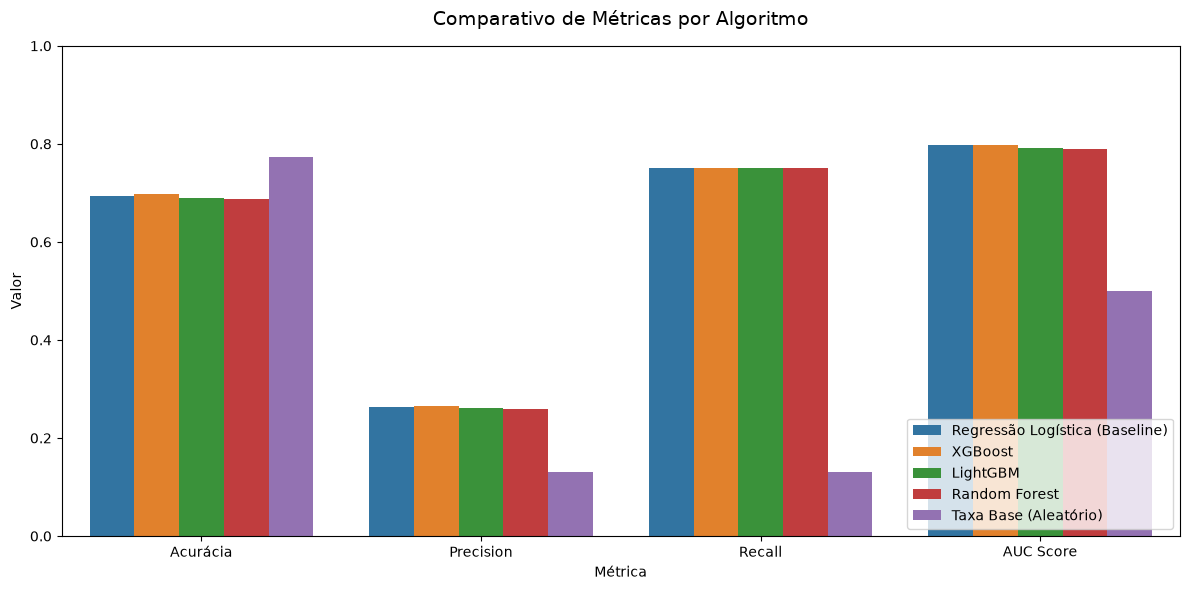

In [3]:
metricas = ['Acurácia', 'Precision', 'Recall', 'AUC Score']

df_plot = df_comparativo.melt(id_vars='Algoritmo', value_vars=metricas, var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Algoritmo')
plt.title('Comparativo de Métricas por Algoritmo', fontsize=14, pad=15)
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 4. Tempo de Treinamento

- Aqui os tempos de treinamento são comparados.
- Essa análise é útil porque um modelo com desempenho semelhante pode ser preferido caso seja mais rápido e mais simples de reexecutar, apesar do tempo ser relativo à maquina.


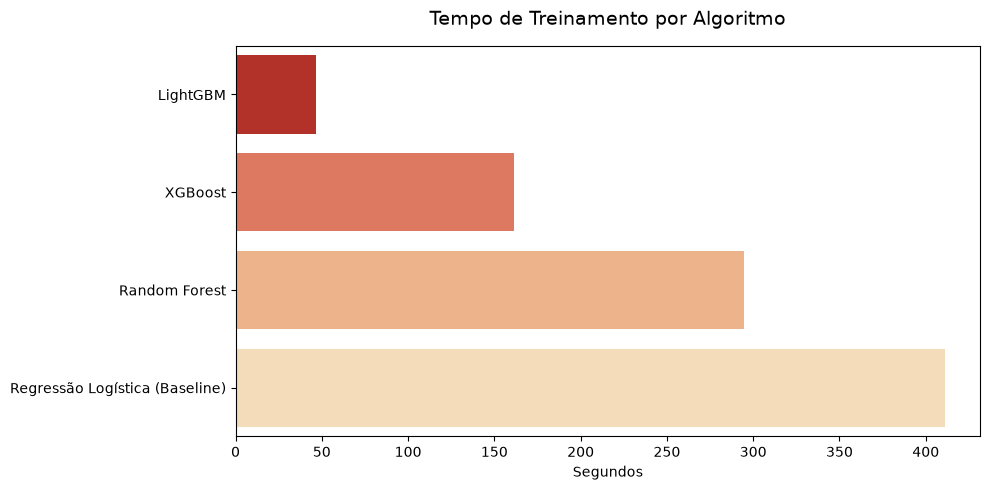

In [4]:
plt.figure(figsize=(10, 5))
ordenado_tempo = df_comparativo.dropna(subset=['Tempo (segundos)']).sort_values(by='Tempo (segundos)')
sns.barplot(data=ordenado_tempo, x='Tempo (segundos)', y='Algoritmo', palette='OrRd_r')
plt.title('Tempo de Treinamento por Algoritmo', fontsize=14, pad=15)
plt.xlabel('Segundos')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 5. Curvas ROC de Todos os Modelos


- Os modelos treinados são recarregados dos arquivos `.pkl` e reavaliados sobre o mesmo `X_test`, gerado por `preparar_dados.carregar_dados`.

### Geração das curvas ROC

- Os modelos salvos são recarregados e avaliados no mesmo conjunto de teste para gerar curvas ROC.


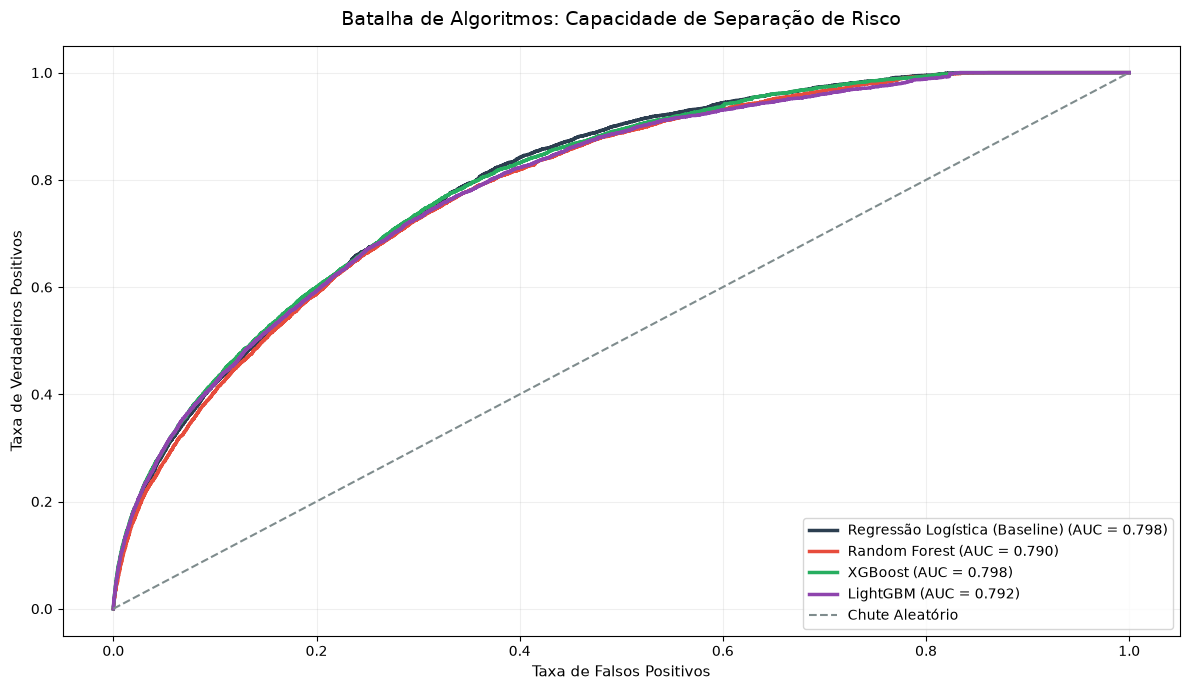

In [5]:
X_train, X_test, y_train, y_test = carregar_dados()

chaves_para_arquivos = {
    'Regressão Logística (Baseline)': '../models/modelo_regressao_logistica.pkl',
    'Random Forest': '../models/modelo_random_forest.pkl',
    'XGBoost': '../models/modelo_xgboost.pkl',
    'LightGBM': '../models/modelo_lightgbm.pkl',
}

plt.figure(figsize=(12, 7))
cores = ['#2c3e50', '#e74c3c', '#27ae60', '#8e44ad']

for (nome, caminho), cor in zip(chaves_para_arquivos.items(), cores):
    modelo = joblib.load(caminho)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_modelo = df_comparativo.loc[df_comparativo['Algoritmo'] == nome, 'AUC Score']
    auc_valor = float(auc_modelo.iloc[0]) if not auc_modelo.empty else float('nan')
    plt.plot(fpr, tpr, color=cor, lw=2.5, label=f"{nome} (AUC = {auc_valor:.3f})")

plt.plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Chute Aleatório')
plt.title('Batalha de Algoritmos: Capacidade de Separação de Risco', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Conclusão

- **AUC Score** é a métrica mais robusta aqui porque o dataset é desbalanceado (~13% de casos graves/fatais); ela mede a capacidade do modelo de separar as classes independente do limiar de decisão.
- **Recall** da classe grave/fatal importa tanto quanto Acurácia neste problema: um modelo que erra a Acurácia mas captura a maioria dos casos graves pode ser preferível para um sistema de alerta de risco.
- **Tempo de treinamento** pesa se o modelo for retreinado com frequência (ex: mensalmente, conforme novos dados da PRF chegam); é menos relevante se o modelo for treinado uma vez e apenas usado para inferência.
- **Nota metodológica:** cada linha do dataset representa uma pessoa envolvida em um acidente (não o acidente em si); acidentes com múltiplos envolvidos geram múltiplas linhas com as mesmas condições de via/clima. O split treino/teste é agrupado por acidente (`GroupShuffleSplit` em `preparar_dados.carregar_dados`, usando o `id` do acidente como grupo), garantindo que os envolvidos de um mesmo acidente não apareçam simultaneamente em treino e teste.